# Importações

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

# Dataset

Boston - Dataset que traz a média de preço de casas de 506 bairros distintos

### Variáveis do Boston Housing Dataset

- **crim**: Taxa de criminalidade per capita por cidade.
- **zn**: Proporção de lotes residenciais com mais de 25.000 pés quadrados.
- **indus**: Proporção de acres de negócios não varejistas por cidade.
- **chas**: Variável dummy (1 se o imóvel está próximo ao rio Charles, 0 caso contrário).
- **nox**: Concentração de óxidos de nitrogênio (indicador de poluição do ar).
- **rm**: Número médio de quartos por residência.
- **age**: Proporção de unidades ocupadas por proprietários construídas antes de 1940.
- **dis**: Distâncias ponderadas até cinco centros de emprego em Boston.
- **rad**: Índice de acessibilidade às rodovias radiais.
- **tax**: Taxa de imposto sobre propriedade por $10.000.
- **ptratio**: Razão aluno/professor por cidade.
- **lstat**: Percentual da população de baixa renda.
- **medv**: Valor médio das casas ocupadas por proprietários (em milhares de dólares).

In [167]:
Boston = load_data("Boston")

In [168]:
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [169]:
Boston.shape

(506, 13)

# Regresão Linear Simples

In [170]:
# Variável Preditória 'lstat' (Percentual de Domicílios com Baixo Nível Socioeconômico)
design = MS(['lstat'])
X = design.fit_transform(Boston) # X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]), 'lstat': Boston['lstat']})

# Variável de interresse 'medv' (Valor Médio da Casa)
y = Boston['medv']

In [171]:
model = sm.OLS(y, X)
results = model.fit()

## Resultados

In [172]:
# Informações do Modelo treinado com uma variável
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           5.08e-88
Time:                        15:21:23   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.0

### Modelo de Regressão Linear Simples

Variável resposta: **medv** (valor médio das casas em milhares de dólares).  
Preditor: **lstat** (percentual de população de baixa renda).  

Modelo estimado:

medv = 34.55 - 0.95 lstat + E

### Interpretação dos coeficientes
- **Intercepto (34.55)**: valor médio esperado das casas quando `lstat = 0`.
- **Coeficiente de lstat (-0.95)**: cada aumento de 1 ponto em `lstat` reduz o valor médio das casas em ~0.95 mil dólares.
- **Intervalo de confiança**: [-1.026, -0.874] → como não inclui 0, confirma significância estatística.

### Estatísticas do modelo
- **R-squared (0.544)**: o modelo explica 54,4% da variabilidade em `medv`.
- **Adj. R-squared (0.543)**: ajustado pelo número de variáveis, praticamente igual (só há uma).
- **F-statistic (601.6)**: teste global do modelo; valor alto indica que `lstat` é um preditor relevante.
- **Prob(F-statistic) (5.08e-88)**: valor-p praticamente zero → modelo altamente significativo.

### Diagnósticos dos resíduos
- **Omnibus/Jarque-Bera**: testes de normalidade dos resíduos; valores altos sugerem que os resíduos não são perfeitamente normais.
- **Skew (1.45)**: indica assimetria positiva nos resíduos.
- **Kurtosis (5.32)**: indica caudas mais pesadas que a normal.
- **Durbin-Watson (0.892)**: sugere autocorrelação positiva nos resíduos (ideal seria próximo de 2).
- **Cond. No. (29.7)**: número de condição; baixo risco de multicolinearidade (só há uma variável).

### Conclusão
O modelo mostra uma relação negativa forte entre `lstat` e `medv`.  
Apesar de significativo, explica apenas parte da variabilidade, indicando que outras variáveis (como `rm`, `nox`, `age`) também devem ser incluídas para melhorar o ajuste.


## Previsões

In [173]:
new_values = pd.DataFrame({'lstat' : [10, 20, 30]})
newX = design.transform(new_values)

In [174]:
new_predictions = results.get_prediction(newX) 

In [175]:
print('Valores Previstos: \n', np.round(new_predictions.predicted_mean, 2))
print('Intervalo de Confiância: \n', np.round(new_predictions.conf_int(alpha=0.05),2))
print('Intervalor de Previsão: \n', np.round(new_predictions.conf_int(obs=True, alpha=0.05),2))

Valores Previstos: 
 [25.05 15.55  6.05]
Intervalo de Confiância: 
 [[24.47 25.63]
 [14.77 16.33]
 [ 4.63  7.48]]
Intervalor de Previsão: 
 [[12.83 37.28]
 [ 3.32 27.79]
 [-6.24 18.35]]


### Previsões e Intervalos 

lstat [10, 20, 30]

- **Valores previstos (predicted mean)**: [25.05, 15.55, 6.05]  
  Representam a média estimada de `medv` para os valores de `lstat` fornecidos.

- **Intervalo de confiança (95%)**:  
  [[24.47, 25.63], [14.77, 16.33], [4.62, 7.48]]  
  Faixa provável para a **média populacional** de `medv`.

- **Intervalo de previsão (95%)**:  
  [[12.83, 37.28], [3.32, 27.79], [-6.24, 18.35]]  
  Faixa provável para uma **observação individual** de `medv`.

**Resumo:**  
O intervalo de confiança mostra a incerteza sobre a média prevista, enquanto o intervalo de previsão mostra a incerteza sobre valores individuais. Por isso, o intervalo de previsão é sempre mais largo.


## Visualizações

In [176]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax" 
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b] 
    ax.plot(xlim, ylim, *args, **kwargs)

### Visualiação da regressão estimada

C:\Users\Fernando Luiz\AppData\Local\Temp\ipykernel_16784\2230797765.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


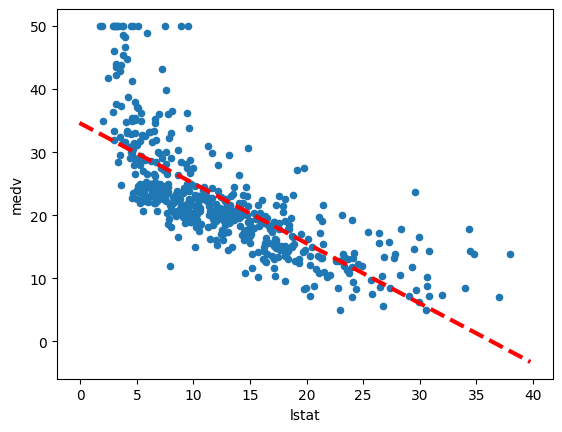

In [177]:
ax = Boston.plot.scatter('lstat', 'medv') 
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)

### Erro residual pelas previsões

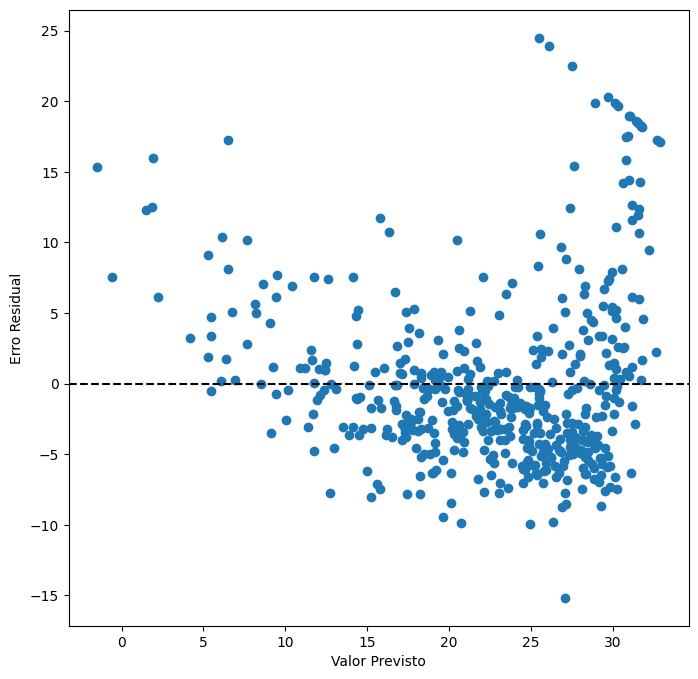

In [178]:
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid) 
ax.set_xlabel('Valor Previsto') 
ax.set_ylabel('Erro Residual')
ax.axhline(0, c='k',ls='--');

- Temos evidências visuais de que existe uma relação não linear entre 'lstat' e 'medv', já que os resíduos parecem não corresponder a uma distribuição aleatória com média 0

### Amostras que geram alavancagem no modelo

np.int64(374)

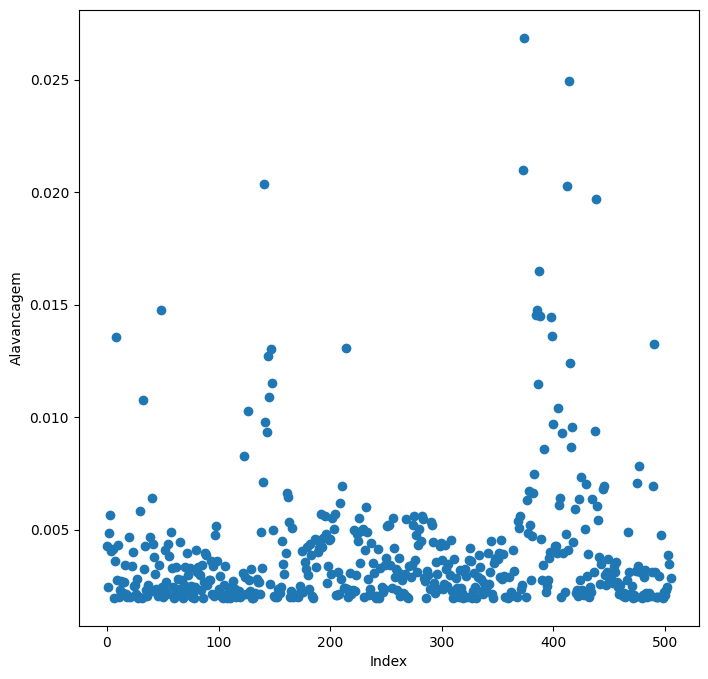

In [179]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8,8))[1] 
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag) 
ax.set_xlabel('Index')
ax.set_ylabel('Alavancagem') 
np.argmax(infl.hat_matrix_diag)

Eixo X (Index): 
- cada ponto representa uma observação do dataset (linha).

Eixo Y (Leverage): 
- valor de alavancagem daquela observação, calculado pela diagonal da matriz chapéu (H)
- mede quão “longe” uma observação está dos valores médios dos preditores
- Observações com leverage alto têm mais influência sobre a reta ajustada

# Regressão Linear Múltipla

In [180]:
y0 = Boston[['medv']]
terms0 = Boston[['lstat', 'age']]
X0 = MS(terms0).fit_transform(Boston)

model0 =  sm.OLS(y0, X0)
results0 =  model0.fit()
print(results0.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.98e-88
Time:                        15:21:24   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     33.2228      0.731     45.458      0.0

In [181]:
y1 = Boston[['medv']]
terms1 = Boston.columns.drop('medv')
X1 = MS(terms1).fit_transform(Boston)

model1 =  sm.OLS(y1, X1)
results1 =  model1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          2.23e-133
Time:                        15:21:24   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.6173      4.936      8.431      0.0

Nota-se que age(idade) e indus(proporção de área industrial) apresentam um p-value alto, mostrando pouca significância estatística para precificar as casas

Removendo temos:

In [182]:
y2 = Boston[['medv']]
terms2 = Boston.columns.drop(['medv', 'age', 'indus'])
X2 = MS(terms2).fit_transform(Boston)

model2 =  sm.OLS(y2, X2)
results2 =  model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     136.8
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          1.73e-135
Time:                        15:21:24   Log-Likelihood:                -1505.0
No. Observations:                 506   AIC:                             3032.
Df Residuals:                     495   BIC:                             3078.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.4517      4.903      8.454      0.0

In [183]:
# R2, R2 ajustado, RSE
print(results1.rsquared, results1.rsquared_adj, results1.scale)
print(results2.rsquared, results2.rsquared_adj, results2.scale)

0.7343070437613076 0.7278398724126984 23.021133485561673
0.7342422518382486 0.7288734084410415 22.933710059207673


- Percebemos uma queda bem pequena em R2 pelo fato das duas variáveis retiradas do modelo terem pouca significância
- Quando olhamos para o R2 ajustado, notamos uma melhora, já que ele penaliza inclusão de variáveis irrelevantes
- O RSE apresentou uma pequena melhora

### VIF - Variance Inflation Factor

Métrica usada em regressão múltipla para detectar multicolinearidade entre os preditores — ou seja, quando uma variável explicativa está altamente correlacionada com outras do modelo.

VIF = 1 → nenhuma correlação com outros preditores.

VIF entre 1 e 5 → correlação moderada, geralmente aceitável.

VIF > 10 → multicolinearidade severa, sinal de problema.

In [184]:
vals = [VIF(X1, i) for i in range(1, X1.shape[1])]
vif = pd.DataFrame({'vif':vals}, index=X1.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


# Transformações não lineares nas variáveis independentes

In [185]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     337.3
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          7.03e-120
Time:                        15:21:24   Log-Likelihood:                -1561.0
No. Observations:                 506   AIC:                             3130.
Df Residuals:                     502   BIC:                             3147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept               

Temos que o p-value para o termo quadrático é aproximadamente 0 mostrando que a relação quadrática entre 'lstat' e a resposta é não linear

## ANOVA

A função anova_lm() serve para realizar uma análise de variância entre modelos de regressão. A ideia é comparar dois ou mais modelos aninhados — ou seja, quando um modelo é uma versão simplificada do outro, com menos termos — e verificar se a inclusão de variáveis adicionais melhora significativamente o ajuste.

In [186]:
# results0 : Com 'lstat' e 'age'
# results3 : Com 'lstat' (termo quadrático) e 'age'

print(anova_lm(results0, results3))

   df_resid           ssr  df_diff      ss_diff           F        Pr(>F)
0     503.0  19168.128609      0.0          NaN         NaN           NaN
1     502.0  14165.613251      1.0  5002.515357  177.278785  7.468491e-35


df_resid = 502, ssr = 14165 → erro menor.

df_diff = 1 → adicionou 1 parâmetro (o termo quadrático).

ss_diff = 5002 → redução significativa no erro.

F = 177.28 → estatística F muito alta.

p‑value = 7.47e‑35 → praticamente zero, indicando que o ganho é altamente significativo.

O teste ANOVA mostra que a inclusão do termo quadrático melhora muito o ajuste do modelo, o p-value extremamente baixo confirma que essa melhoria não é fruto do acaso.

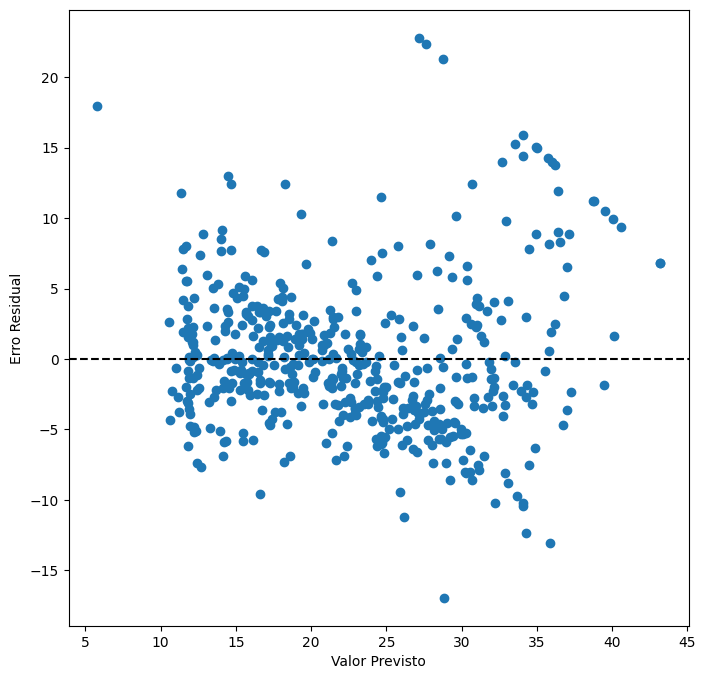

In [187]:
ax = plt.subplots(figsize=(8,8))[1] 
ax.scatter(results3.fittedvalues, results3.resid) 
ax.set_xlabel('Valor Previsto') 
ax.set_ylabel('Erro Residual')
ax.axhline(0, c='k',ls='--')

Analisando o gráfico de Erro residual, pelo valor previsto notamos um certo aleatoridade, indicando uma melhora no nosso modelo.

# Preditores Qualitativos

In [188]:
Carseates = load_data('Carseats')
Carseates.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [189]:
Carseates.sample(5)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
276,6.93,135,69,14,296,130,Medium,73,15,Yes,Yes
128,4.96,133,100,3,350,126,Bad,55,13,Yes,Yes
85,8.47,125,103,0,304,112,Medium,49,13,No,No
92,4.53,114,113,0,97,125,Medium,29,12,Yes,No
26,8.33,107,115,11,496,131,Good,50,11,No,Yes


In [ ]:
var = Carseates.columns.drop(['Sales'])
y = Carseates['Sales']
X = MS(var).fit_transform(Carseates)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     243.4
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          1.60e-166
Time:                        15:21:24   Log-Likelihood:                -568.99
No. Observations:                 400   AIC:                             1162.
Df Residuals:                     388   BIC:                             1210.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             5.6606      0.60

ModelSpec() já realiza o one-hot encoding das variáveis categóricas

# Resumo


## 1. Coeficientes e p-value
- **Coeficiente**: indica direção e magnitude do efeito da variável independente sobre a resposta.
- **p-value**: probabilidade de o efeito observado ser fruto do acaso.
  - p < 0,05 → variável estatisticamente significativa.
  - p > 0,05 → não há evidência suficiente de relevância.

---

## 2. R² (Coeficiente de determinação)
- Mede a proporção da variância explicada pelo modelo.
- **R² próximo de 1** → modelo explica bem os dados.
- **R² baixo** → modelo não captura a variabilidade.
- **R² ajustado**: corrige pelo número de variáveis, evitando inflar o valor com termos irrelevantes.

---

## 3. Estatística F
- Testa se o conjunto de variáveis independentes, em conjunto, explica significativamente a resposta.
- **F alto e p-value baixo** → o modelo como um todo é relevante.
- Útil para verificar se vale a pena usar regressão em vez de um modelo sem variáveis.

---

## 4. Erros médios
- **MSE (Mean Squared Error)**: média dos quadrados dos erros. Penaliza fortemente erros grandes.
- **RMSE (Root Mean Squared Error)**: raiz do MSE, volta à escala original da variável resposta.
- **MAE (Mean Absolute Error)**: média dos erros absolutos, mais robusto contra outliers.
- Avaliam a **precisão preditiva** do modelo.

---

## 5. Análise de resíduos
- **Resíduos**: diferenças entre valores observados e previstos.
- Avaliar se os resíduos têm:
  - Distribuição normal
  - Variância constante (homocedasticidade)
  - Independência
- Gráficos de resíduos ajudam a identificar problemas como heterocedasticidade ou não linearidade.

---

## Interpretação em conjunto
- **p-value baixo** → variável relevante estatisticamente.
- **Coeficiente alto** → impacto forte na resposta.
- **R² alto** → modelo explica bem os dados.
- **F significativo** → modelo globalmente útil.
- **MSE/RMSE/MAE baixos** → previsões precisas.
- **Resíduos bem comportados** → suposições atendidas, modelo confiável.

---

## Pontos de atenção
- **Multicolinearidade** pode inflar p-values e distorcer coeficientes.
- **Overfitting**: incluir muitas variáveis pode aumentar R² mas reduzir generalização.
- **Significância ≠ importância prática**: uma variável pode ser estatisticamente significativa mas ter efeito pequeno demais para ser relevante em termos de negócio ou ciência.
